## Demand Forecasting & Revenue Prediction Engine

Now that the core of Business Intelligence modeling and visualization for Analytical Insights has been done, we move on to:

* **Predicting Future Revenue to guide inventory, marketing, and growth strategy and, on the whole, enable proactive decision-making.**

In [1]:
import pandas as pd
import numpy as np

# Data Prep

df = pd.read_csv('df_final.csv')

In [39]:
df['RevenueLag_7Days'] = df['Revenue'].shift(7)
ts = df.groupby('InvoiceDate')['Revenue'].sum().reset_index()
ts['InvoiceDate'] = pd.to_datetime(ts['InvoiceDate'])
ts.set_index('InvoiceDate', inplace = True)

ts = ts.asfreq('D').fillna(0)

ts.head(6)

,DayOfWeek,Revenue,RevenueLag_1Day,RevenueLag_7Days
InvoiceDate,,,,
2011-03-17,1056.0,2899.21,3093.13,2848.45
2011-03-18,4660.0,19972.92,8596.76,19908.68
2011-03-19,0.0,0.00,0.00,0.00
2011-03-20,8029.0,18459.00,18288.89,18449.80
2011-03-21,933.0,15179.17,15123.23,15162.03
2011-03-22,2124.0,15655.40,15446.95,15753.09


In [40]:
# Splitting Data for the Baseline Model and Subsequent LSTM Model

train = ts[:-30]
test = ts[-30:]

In [42]:
# ARIMA (Baseline + CI) [Statistical Learning]

from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train['Revenue'], order = (1, 1, 1)).fit()
forecast = arima.get_forecast(steps = len(test))

pred_arima = forecast.predicted_mean
conf_int = forecast.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


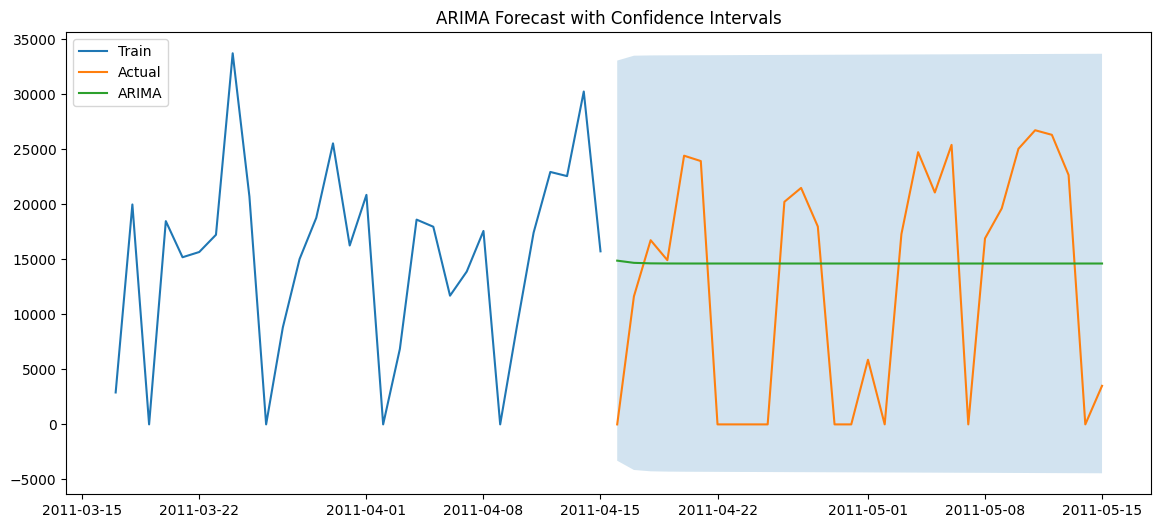

In [25]:
# Plotting ARIMA

plt.figure(figsize = (14, 6))
plt.plot(train.index, train['Revenue'], label = 'Train')
plt.plot(test.index, test['Revenue'], label = 'Actual')
plt.plot(test.index, pred_arima, label = 'ARIMA')

plt.fill_between(test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha = 0.2)

plt.legend()
plt.title("ARIMA Forecast with Confidence Intervals")
plt.show()

In [26]:
# LSTM (Proper Train/Test) [Deep Learning]
# Scaling separately

from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train['Revenue'])
test_scaled = scaler.transform(test['Revenue'])

# Creating Sequences

def create_seq(data, window = 7):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i: i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

X_train, y_train = create_seq(train_scaled)
X_test, y_test = create_seq(test_scaled)

In [28]:
# Training the LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, input_shape = (X_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer = 'adam', loss = 'mse')
model.fit(X_train, y_train, epochs = 10, batch_size = 16, verbose = 0)

In [29]:
# Predicting based on the LSTM Model

pred_lstm = model.predict(X_test)

pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


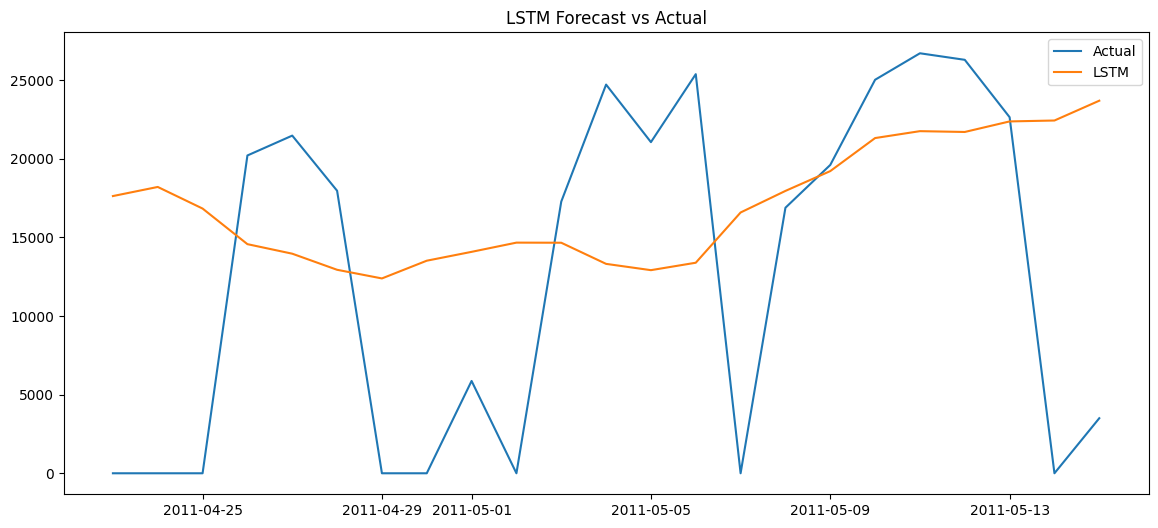

In [30]:
# Plotting the LSTM Model

plt.figure(figsize = (14, 6))
plt.plot(test.index[-len(y_test_actual):], y_test_actual, label = 'Actual')
plt.plot(test.index[-len(pred_lstm):], pred_lstm, label = 'LSTM')
plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()

In [47]:
# Model Evaluation & Comparison

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(test['Revenue'], pred_arima))
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, pred_lstm))

print(f"ARIMA RMSE: {rmse_arima:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")

ARIMA RMSE: 10616.64
LSTM RMSE: 11891.78
Multivariate LSTM RMSE: 12079.08


### **Interpretation:**

ARIMA (a simpler model) outperforms LSTM (a complex one), with a lower RMSE score of 10,617 compared to LSTM's 11,892.

**Given ARIMA’s accuracy and interpretability, it is better suited for operational forecasting, enabling clearer communication of uncertainty and more reliable planning.**

Possible explanations:

* The dataset was not large enough for LSTM, as Deep Learning requires a LOT of data.
* The pattern within the dataset might have been quite straightforward, which is perfect for ARIMA to grasp.
* LSTM might have been limited by a Univariate variable (Revenue), low epochs (10), and the absence of exogenous features.

---

* ARIMA provides stable forecasts with uncertainty bounds (risk-aware planning)
* LSTM captures nonlinear demand patterns but lacks interpretability
* Trade-off: Explainability vs Predictive Power